In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import folium

In [2]:
# Load the dataset
df = pd.read_csv("/content/Real estate.csv")
# Display first 5 rows
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
# Display information about the dataset
df.info()
# Display statistical summary
df.describe()
# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [6]:
# Select the features for clustering
features = df[['X2 house age',
               'X3 distance to the nearest MRT station',
               'X4 number of convenience stores',
               'X5 latitude',
               'X6 longitude',
               'Y house price of unit area']]
# Display the first 5 rows of the selected features
features.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


In [7]:
# Create the StandardScaler object
scaler = StandardScaler()
# Scale the selected features
scaled_data = scaler.fit_transform(features)
# Display the scaled data
print(scaled_data)

[[ 1.25562833 -0.79249504  2.00740743  1.12542986  0.44876222 -0.00590088]
 [ 0.15708622 -0.61661163  1.66750286  0.91244418  0.40113894  0.3105072 ]
 [-0.38779067 -0.41401527  0.30788458  1.48686011  0.68818339  0.6857819 ]
 ...
 [ 0.09556786 -0.54967846  0.98769372  0.82289338  0.42397202  0.19277396]
 [-0.84478419 -0.77668389  0.30788458 -0.18475479  0.4768143   1.06841493]
 [-0.98539758 -0.78807071  1.66750286  0.42757905  0.63534112  1.90726426]]


In [8]:
# Create an empty list to store WCSS values
wcss = []
# Calculate WCSS for cluster numbers from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

In [9]:
# Create the K-Means model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
# Train the model and assign each house to a cluster
clusters = kmeans.fit_predict(scaled_data)
# Add the cluster labels to the original dataset
df['Cluster'] = clusters
# Display the first 10 rows
df.head(10)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Cluster
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,1
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,1
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,1
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,1
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1,3
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3,2
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7,1
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8,0
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1,3


In [10]:
# Import PCA
from sklearn.decomposition import PCA
# Create a PCA object to reduce data to 2 dimensions
pca = PCA(n_components=2)
# Transform the scaled data
pca_data = pca.fit_transform(scaled_data)
# Display the first 5 transformed data points
print(pca_data[:5])

[[-1.83729228  1.6885482 ]
 [-1.6873172   0.48650965]
 [-1.57101065 -0.2253957 ]
 [-1.823601   -0.34490501]
 [-1.22182909 -0.95340128]]


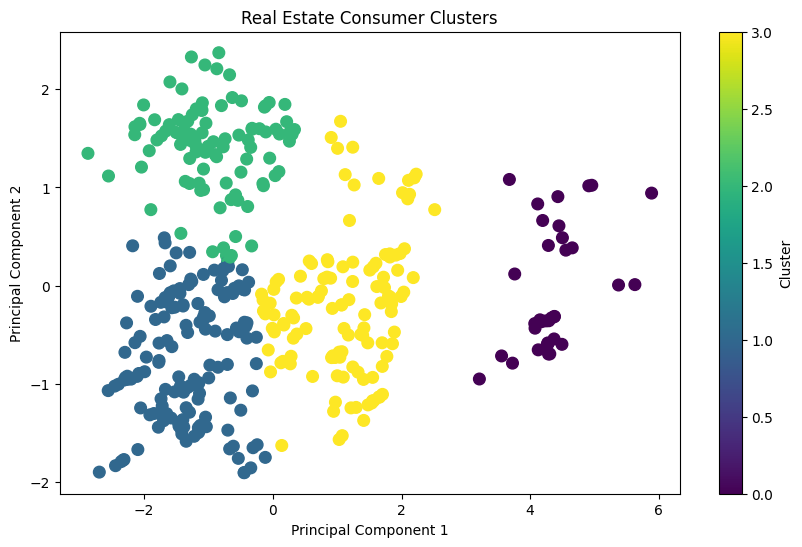

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)
plt.title("Real Estate Consumer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

In [12]:
# Create a map centered on the average latitude and longitude
real_estate_map = folium.Map(
    location=[df['X5 latitude'].mean(), df['X6 longitude'].mean()],
    zoom_start=13
)
# Display the empty map
real_estate_map

In [14]:
colors = ['red', 'blue', 'green', 'purple']

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['X5 latitude'], row['X6 longitude']],
        radius=5,
        color=colors[int(row['Cluster'])],
        fill=True,
        fill_color=colors[int(row['Cluster'])],
        fill_opacity=0.7,
        popup=f"""
        Cluster: {int(row['Cluster'])}<br>
        Price: {row['Y house price of unit area']}<br>
        House Age: {row['X2 house age']}
        """
    ).add_to(real_estate_map)

real_estate_map

In [15]:
# Save the clustered dataset to a CSV file
df.to_csv("Real_Estate_Clustered.csv", index=False)
print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


In [16]:
from google.colab import files

files.download("Real_Estate_Clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import os

print(os.listdir())

['.config', 'Real estate.csv', 'Real_Estate_Clustered.csv', 'sample_data']


In [19]:
real_estate_map.save("Real_Estate_Clusters.html")

print("Map saved successfully!")

Map saved successfully!


In [20]:
import os

print(os.listdir())

['.config', 'Real estate.csv', 'Real_Estate_Clusters.html', 'Real_Estate_Clustered.csv', 'sample_data']


In [21]:
from google.colab import files

files.download("Real_Estate_Clusters.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>